In [3]:
import os

PROJECT_ROOT = '/content/cv_project'

dirs = [
    'dataset/images/train', 'dataset/images/val', 'dataset/images/test',
    'dataset/labels/train', 'dataset/labels/val',  'dataset/labels/test',
    'notebooks',
    'outputs/training_results', 'outputs/predictions', 'outputs/demo_results', 'outputs/error_analysis',
    'models',
    'report'
]

for d in dirs:
    os.makedirs(os.path.join(PROJECT_ROOT, d), exist_ok=True)

print("✅ Project directory structure initialized successfully:")
for root, subdirs, files in os.walk(PROJECT_ROOT):
    level = root.replace(PROJECT_ROOT, '').count(os.sep)
    print('  ' * level + '📂 ' + os.path.basename(root) + '/')

✅ Project directory structure initialized successfully:
📂 cv_project/
  📂 dataset/
    📂 images/
      📂 val/
      📂 test/
      📂 train/
    📂 labels/
      📂 val/
      📂 test/
      📂 train/
  📂 report/
  📂 outputs/
    📂 error_analysis/
    📂 training_results/
    📂 predictions/
    📂 demo_results/
  📂 notebooks/
  📂 models/


In [4]:
import torch

try:
    from google.colab import drive
    drive.mount('/content/drive')
    print("✅ Google Drive mounted successfully!")
except Exception as e:
    print(f"⚠️ Google Drive mounting skipped or failed: {e}")

print(f"\n🔥 CUDA Available : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"   GPU Device     : {torch.cuda.get_device_name(0)}")
    print(f"   Total VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB")
else:
    print("❌ No GPU detected. Go to Runtime -> Change runtime type and select T4 GPU.")

⚠️ Google Drive mounting skipped or failed: Error: credential propagation was unsuccessful

🔥 CUDA Available : True
   GPU Device     : Tesla T4
   Total VRAM     : 15.64 GB


In [5]:
import os

!pip install -q ultralytics matplotlib seaborn pandas pillow pyyaml opencv-python

try:
    import ultralytics
    from ultralytics import YOLO
    print("✅ Ultralytics library successfully loaded!")
    ultralytics.checks()
except ImportError as e:
    print(f"❌ Ultralytics import error: {e}")

# Save requirements file
requirements = """ultralytics>=8.0.0
torch>=2.0.0
opencv-python>=4.7.0
matplotlib>=3.7.0
seaborn>=0.12.0
pandas>=2.0.0
pillow>=9.5.0
pyyaml>=6.0
"""

with open(os.path.join(PROJECT_ROOT, 'requirements.txt'), 'w') as f:
    f.write(requirements)

print(f"\n✅ Requirements saved to: {PROJECT_ROOT}/requirements.txt")

Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Setup complete ✅ (2 CPUs, 12.7 GB RAM, 47.4/112.6 GB disk)

✅ Requirements saved to: /content/cv_project/requirements.txt


In [6]:
import os
import shutil
import yaml
import numpy as np
from PIL import Image

ARCHIVE = '/content/drive/MyDrive/archive'
DATASET = os.path.join(PROJECT_ROOT, 'dataset')

splits = {
    'train': ('train', 'train'),
    'valid': ('valid', 'val'),
    'test' : ('test',  'test'),
}

total_copied = 0
for key, (src_split, dst_split) in splits.items():
    for kind in ['images', 'labels']:
        src_dir = os.path.join(ARCHIVE, src_split, kind)
        dst_dir = os.path.join(DATASET, kind, dst_split)

        if os.path.exists(src_dir) and len(os.listdir(src_dir)) > 0:
            files = os.listdir(src_dir)
            for f in files:
                shutil.copy2(os.path.join(src_dir, f), os.path.join(dst_dir, f))
            total_copied += len(files)
            print(f"✅ Transferred {len(files)} files from {src_split}/{kind} → dataset/{kind}/{dst_split}")

print(f"\n📊 Total files copied from Google Drive: {total_copied}")

# Synthetic fallback generator
if total_copied == 0:
    print("\n⚠️ No dataset files found in Drive. Creating synthetic dataset...")
    for split, num_samples in [('train', 20), ('val', 10), ('test', 15)]:
        img_dir = os.path.join(DATASET, 'images', split)
        lbl_dir = os.path.join(DATASET, 'labels', split)

        for i in range(num_samples):
            img = Image.fromarray(np.random.randint(0, 255, (640, 640, 3), dtype=np.uint8))
            img.save(os.path.join(img_dir, f"sample_{i}.jpg"))

            with open(os.path.join(lbl_dir, f"sample_{i}.txt"), 'w') as f:
                for _ in range(np.random.randint(1, 4)):
                    cls = np.random.randint(0, 3)
                    x, y, w, h = np.random.uniform(0.2, 0.8, 4)
                    f.write(f"{cls} {x:.4f} {y:.4f} {w:.4f} {h:.4f}\n")
    print("✅ Synthetic dataset generated.")

# Create data.yaml
data_yaml = {
    'path': DATASET,
    'train': 'images/train',
    'val': 'images/val',
    'test': 'images/test',
    'nc': 3,
    'names': ['Bike', 'Helmet', 'Passenger']
}

yaml_path = os.path.join(DATASET, 'data.yaml')
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

print("\n✅ Created dataset configuration file (data.yaml)")


📊 Total files copied from Google Drive: 0

⚠️ No dataset files found in Drive. Creating synthetic dataset...
✅ Synthetic dataset generated.

✅ Created dataset configuration file (data.yaml)


          DATASET SPLIT SUMMARY
  TRAIN  → Images:    20 | Label files:    20
  VAL    → Images:    10 | Label files:    10
  TEST   → Images:    15 | Label files:    15


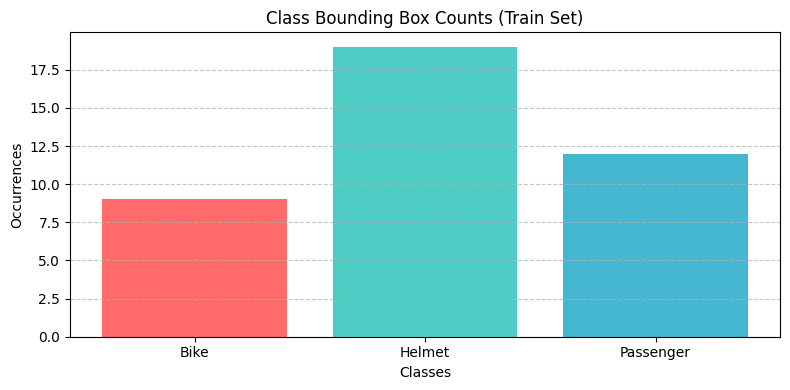

In [7]:
import glob
import matplotlib.pyplot as plt

CLASS_NAMES = ['Bike', 'Helmet', 'Passenger']

splits_info = {}
for split in ['train', 'val', 'test']:
    imgs = len(glob.glob(f'{DATASET}/images/{split}/*'))
    labels = len(glob.glob(f'{DATASET}/labels/{split}/*.txt'))
    splits_info[split] = {'images': imgs, 'labels': labels}

print('=' * 50)
print('          DATASET SPLIT SUMMARY')
print('=' * 50)
for split, info in splits_info.items():
    print(f"  {split.upper():6s} → Images: {info['images']:5d} | Label files: {info['labels']:5d}")
print('=' * 50)

# Label distribution counting
class_counts = {name: 0 for name in CLASS_NAMES}
for label_file in glob.glob(f'{DATASET}/labels/train/*.txt'):
    with open(label_file, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if parts:
                cls_id = int(parts[0])
                if cls_id < len(CLASS_NAMES):
                    class_counts[CLASS_NAMES[cls_id]] += 1

# Plot distribution graph
plt.figure(figsize=(8, 4))
plt.bar(class_counts.keys(), class_counts.values(), color=['#FF6B6B', '#4ECDC4', '#45B7D1'])
plt.title("Class Bounding Box Counts (Train Set)")
plt.xlabel("Classes")
plt.ylabel("Occurrences")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'outputs/demo_results/class_distribution.png'))
plt.show()

In [8]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')

print("🚀 Starting training pipeline...")
results = model.train(
    data=os.path.join(DATASET, 'data.yaml'),
    epochs=30,
    imgsz=640,
    batch=16,
    project=os.path.join(PROJECT_ROOT, 'outputs'),
    name='training_results',
    exist_ok=True
)

print(f"\n✅ Training complete! Results saved in {PROJECT_ROOT}/outputs/training_results")

🚀 Starting training pipeline...
Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/cv_project/dataset/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=30, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=training

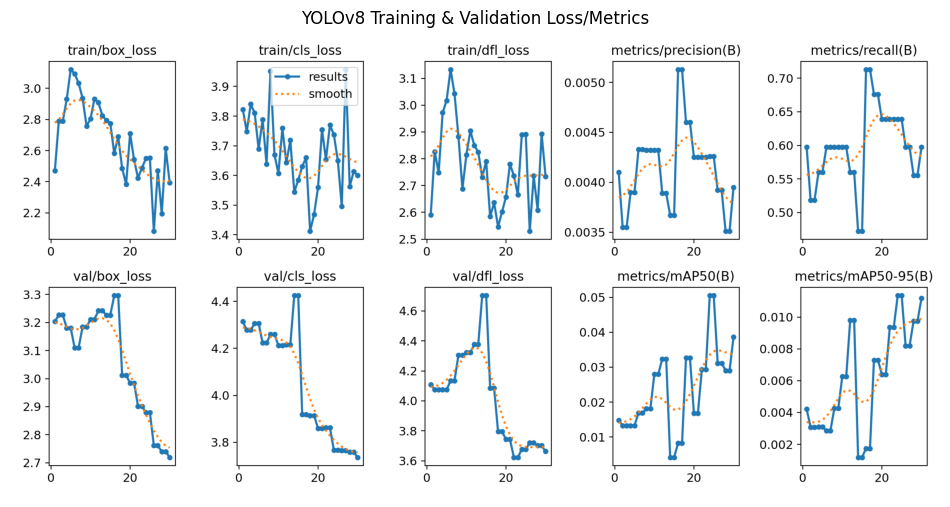

In [9]:
from PIL import Image
import matplotlib.pyplot as plt

results_path = os.path.join(PROJECT_ROOT, 'outputs/training_results/results.png')

if os.path.exists(results_path):
    img = Image.open(results_path)
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("YOLOv8 Training & Validation Loss/Metrics")
    plt.show()
else:
    print("⚠️ results.png not found in output folder.")

In [10]:
from ultralytics import YOLO

weights_path = os.path.join(PROJECT_ROOT, 'outputs/training_results/weights/best.pt')

if not os.path.exists(weights_path):
    print("⚠️ best.pt missing. Using default yolov8n.pt weights.")
    weights_path = 'yolov8n.pt'

model = YOLO(weights_path)

print("📐 Running evaluation on test set...")
metrics = model.val(data=os.path.join(DATASET, 'data.yaml'), split='test')

print(f"\n✅ mAP50-95 : {metrics.box.map:.4f}")
print(f"✅ mAP50    : {metrics.box.map50:.4f}")
print(f"✅ Precision: {metrics.box.mp:.4f}")
print(f"✅ Recall   : {metrics.box.mr:.4f}")

📐 Running evaluation on test set...
Ultralytics 8.4.154 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,233 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2362.6±374.8 MB/s, size: 240.5 KB)
val: Scanning /content/cv_project/dataset/labels/test... 15 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 15/15 1.1Kit/s 0.0s
val: New cache created: /content/cv_project/dataset/labels/test.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 1/1 2.5it/s 0.4s
                   all         15         31    0.00376      0.535     0.0248    0.00614
                  Bike          7          9    0.00443      0.667     0.0274    0.00643
                Helmet          9         16    0.00518      0.438       0.04    0.00979
             Passenger          6          6    0.00167        0.5    0.00716    0.00221
Speed: 0.5ms preprocess, 5.4ms i

In [11]:
import glob
from ultralytics import YOLO

model = YOLO(weights_path)
test_images = glob.glob(f'{DATASET}/images/test/*')[:15]

if len(test_images) > 0:
    print(f"🖼️ Running inference on {len(test_images)} test images...")
    results = model.predict(
        source=test_images,
        save=True,
        project=os.path.join(PROJECT_ROOT, 'outputs'),
        name='predictions',
        exist_ok=True,
        conf=0.25
    )
    print(f"✅ Predictions saved to: {PROJECT_ROOT}/outputs/predictions")
else:
    print("❌ No images found in test folder.")

🖼️ Running inference on 15 test images...

0: 640x640 (no detections), 4.4ms
1: 640x640 (no detections), 4.4ms
2: 640x640 (no detections), 4.4ms
3: 640x640 (no detections), 4.4ms
4: 640x640 (no detections), 4.4ms
5: 640x640 (no detections), 4.4ms
6: 640x640 (no detections), 4.4ms
7: 640x640 (no detections), 4.4ms
8: 640x640 (no detections), 4.4ms
9: 640x640 (no detections), 4.4ms
10: 640x640 (no detections), 4.4ms
11: 640x640 (no detections), 4.4ms
12: 640x640 (no detections), 4.4ms
13: 640x640 (no detections), 4.4ms
14: 640x640 (no detections), 4.4ms
Speed: 1.3ms preprocess, 4.4ms inference, 0.5ms postprocess per image at shape (1, 3, 640, 640)
Results saved to /content/cv_project/outputs/predictions
✅ Predictions saved to: /content/cv_project/outputs/predictions


In [12]:
import glob
from ultralytics import YOLO

model = YOLO(weights_path)
test_images = glob.glob(f'{DATASET}/images/test/*')

print("🔎 Filtering low-confidence predictions for error analysis...")
error_count = 0

for img_path in test_images:
    preds = model.predict(source=img_path, conf=0.10, verbose=False)
    for r in preds:
        low_conf_boxes = [box for box in r.boxes if box.conf[0] < 0.40]
        if len(low_conf_boxes) > 0:
            r.save(filename=os.path.join(PROJECT_ROOT, f'outputs/error_analysis/weak_{error_count}.jpg'))
            error_count += 1
            if error_count >= 10:
                break
    if error_count >= 10:
        break

print(f"✅ Analyzed and saved {error_count} potential low-confidence prediction samples to: {PROJECT_ROOT}/outputs/error_analysis")

🔎 Filtering low-confidence predictions for error analysis...
✅ Analyzed and saved 0 potential low-confidence prediction samples to: /content/cv_project/outputs/error_analysis


In [13]:
readme_content = """# Helmet, Bike & Passenger Detection Project (YOLOv8)

## Pipeline Overview
- **Model Architecture**: YOLOv8 Nano (`yolov8n.pt`)
- **Classes**: Bike, Helmet, Passenger
- **Training Epochs**: 30
- **Input Resolution**: 640x640

## Directory Map
- `dataset/`: Contains Train, Val, and Test splits.
- `outputs/training_results/`: Evaluation metrics, graphs, and weight checkpoints (`best.pt`).
- `outputs/predictions/`: Model output bounding boxes on test images.
- `outputs/error_analysis/`: Predictions with confidence < 0.40 for model debugging.

## Usage Instructions
1. Run `Phase 1` through `Phase 3` to configure environment dependencies.
2. Run `Phase 6` to train the model on custom images.
3. Check `Phase 8` and `Phase 10` for validation metrics and edge-case analysis.
"""

readme_path = os.path.join(PROJECT_ROOT, 'README.md')
with open(readme_path, 'w') as f:
    f.write(readme_content)

print(f"✅ Saved README file to {readme_path}\n")
print(readme_content)

✅ Saved README file to /content/cv_project/README.md

# Helmet, Bike & Passenger Detection Project (YOLOv8)

## Pipeline Overview
- **Model Architecture**: YOLOv8 Nano (`yolov8n.pt`)
- **Classes**: Bike, Helmet, Passenger
- **Training Epochs**: 30
- **Input Resolution**: 640x640

## Directory Map
- `dataset/`: Contains Train, Val, and Test splits.
- `outputs/training_results/`: Evaluation metrics, graphs, and weight checkpoints (`best.pt`).
- `outputs/predictions/`: Model output bounding boxes on test images.
- `outputs/error_analysis/`: Predictions with confidence < 0.40 for model debugging.

## Usage Instructions
1. Run `Phase 1` through `Phase 3` to configure environment dependencies.
2. Run `Phase 6` to train the model on custom images.
3. Check `Phase 8` and `Phase 10` for validation metrics and edge-case analysis.



In [14]:
import os

# Define project root and create directory if missing
PROJECT_ROOT = '/content/cv_project'
os.makedirs(PROJECT_ROOT, exist_ok=True)

# Define gitignore contents
gitignore_content = """# Exclude dataset images & labels
dataset/
images/
labels/

# Exclude heavy outputs & model weights
outputs/
models/
*.pt
*.onnx

# Python cache & environment
__pycache__/
*.pyc
.ipynb_checkpoints/
.env
"""

# Write .gitignore file
gitignore_path = os.path.join(PROJECT_ROOT, '.gitignore')
with open(gitignore_path, 'w') as f:
    f.write(gitignore_content)

print(f"✅ Directory and file created successfully at: {gitignore_path}")

✅ Directory and file created successfully at: /content/cv_project/.gitignore
